# Supervisor Agent란?

**Supervisor Agent**는 Hierarchical Agent의 특수한 형태로, 여러 전문 에이전트들을 **관리하고 조율**하는 역할을 합니다.

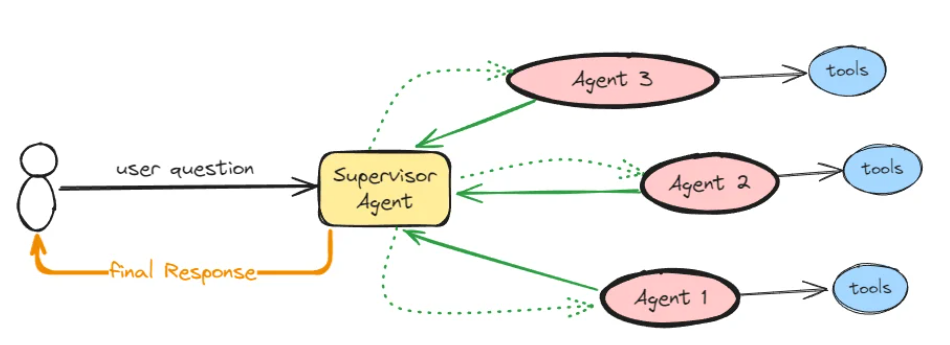



## 주요 특징
1. **중앙 집중식 제어**: Supervisor가 전체 워크플로우를 관리
2. **동적 작업 배분**: 상황에 따라 적절한 에이전트에게 작업 할당
3. **결과 종합**: 여러 에이전트의 결과를 수집하고 통합
4. **순차적 조율**: 필요시 에이전트 간 작업 순서 조정

## vs. 단순 Hierarchical Agent
- **Hierarchical**: 단순히 작업을 분류하여 해당 에이전트로 전달 (1회성)
- **Supervisor**: 전체 프로세스를 관리하며, 여러 에이전트를 순차적으로 호출하고 결과를 통합 (다단계)

# Supervisor Agents - 블로그 콘텐츠 제작 시스템

Supervisor Agent 패턴을 활용하여 블로그 콘텐츠를 자동으로 제작하는 시스템을 구현합니다.


## 시스템 구성

### 에이전트 구조
```
                    Supervisor Agent
                    (콘텐츠 제작 관리자)
                           |
         +-----------------+-----------------+
         |                 |                 |
    Research Agent    Writer Agent      SEO Agent
    (자료 조사)        (초안 작성)       (SEO 최적화)
         |                 |                 |
         +-----------------+-----------------+
                           |
                    Editor Agent
                    (최종 편집)
```

### 작업 흐름
1. **Supervisor**: 블로그 주제를 분석하고 작업 계획 수립
2. **Research Agent**: 주제 관련 정보 조사 및 핵심 포인트 추출
3. **Writer Agent**: 조사 자료를 바탕으로 초안 작성
4. **SEO Agent**: 키워드 최적화 및 SEO 권장사항 제시
5. **Editor Agent**: 최종 편집 및 교정
6. **Supervisor**: 모든 결과를 종합하여 최종 콘텐츠 생성


## 학습 목표

- Supervisor Agent의 역할과 책임 이해
- 다단계 워크플로우 설계 및 구현
- 에이전트 간 데이터 전달 및 상태 관리
- 동적 작업 조율 (Dynamic Task Orchestration)


## 1단계: LLM 모델 초기화


In [1]:
from dotenv import load_dotenv

# dotenv 파일에서 환경변수 로드
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano"
)

## 2단계: 상태 정의 (State Management)

Supervisor Agent 시스템에서는 여러 에이전트가 순차적으로 작업하므로, 각 단계의 결과를 저장할 수 있는 복잡한 상태 구조가 필요합니다.


In [3]:
from typing import TypedDict, Literal

# total=False는 TypedDict의 모든 필드를 선택적(optional)으로 만드는 옵션
class ContentState(TypedDict, total=False):
    """
    블로그 콘텐츠 제작 시스템의 상태를 정의하는 클래스
    """
    # 입력
    topic: str                      # 블로그 주제
    target_audience: str            # 타겟 독자층
    
    # Supervisor 관리
    current_step: str               # 현재 진행 단계
    retry_counts: dict              # 에이전트별 재시도 횟수 {"research_data": 0, ...}
    
    # 각 에이전트의 작업 결과
    research_data: str              # Research Agent의 조사 결과
    draft_content: str              # Writer Agent의 초안
    seo_recommendations: str        # SEO Agent의 권장사항
    edited_content: str             # Editor Agent의 최종 편집본
    
    # 최종 출력
    final_blog_post: str            # 완성된 블로그 포스트
    status: Literal['in_progress', 'completed']  # 작업 상태

## 3단계: 전문 에이전트 정의

각 에이전트는 특정 영역의 전문가 역할을 수행합니다.


### Research Agent (조사 에이전트)

주제에 대한 핵심 정보를 조사하고 정리합니다.


In [4]:
from langchain_tavily import TavilySearch

search_langchain = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=False,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="advanced",          # "basic" 또는 "advanced"
    include_domains=[
        "https://docs.langchain.com/oss/python/langchain/overview",
        "https://docs.langchain.com/oss/python/langgraph/overview",
        "https://docs.langchain.com/oss/python/deepagents/overview" 
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [5]:
from langchain.tools import tool

@tool
def search_topic_of_langchain(topic:str) -> str:
    """ Tavily를 이용한 사전 리서치 """
    search_results = search_langchain.invoke({
        "query": topic
    })

    # Tavily 결과 정리 (answer + search results)
    tavily_context = []

    if "answer" in search_results and search_results["answer"]:
        tavily_context.append(f"[요약 답변]\n{search_results['answer']}")

    if "results" in search_results:
        for idx, r in enumerate(search_results["results"], 1):
            tavily_context.append(
                f"[자료 {idx}]\n"
                f"- 제목: {r.get('title')}\n"
                f"- 출처: {r.get('url')}\n"
                f"- 내용 요약: {r.get('content')}"
            )

    tavily_context_text = "\n\n".join(tavily_context)
    return tavily_context_text

In [ ]:
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent

def research_agent(state: ContentState) -> ContentState:
    """
    주제에 대한 조사를 수행하는 에이전트 (Tavily 검색 포함)
    """
    topic = state["topic"]
    target_audience = state["target_audience"]
    agent = create_agent(
        model=llm,
        tools=[search_topic_of_langchain],
        system_prompt="""당신은 전문 리서처입니다.
적절할 툴을 사용하여 신뢰할 수 있는 공식 문서 기반 웹 리서치 데이터를 수집한 후 아래 요구사항에 맞게 진행해주세요.

이 정보를 최우선 근거로 사용하여 조사를 수행하세요.

다음 항목을 조사하여 정리하세요:

1. 주제의 핵심 개념 및 정의
2. 주요 트렌드 및 최신 동향
3. 독자들이 궁금해할 만한 점 3가지
4. 실용적인 팁이나 인사이트
5. 관련 통계나 데이터 (있다면)

✔ 간결하고 구조화된 형태로 작성
✔ 불확실한 내용은 추측하지 말 것
✔ 공식 문서 기준으로 설명할 것""")

    response = agent.invoke(
        {"messages": HumanMessage(content=f"""주제: {topic}
타겟 독자: {target_audience}

위 정보를 바탕으로 조사 결과를 작성해주세요.
""")})

    # LLM 호출
    research_data = response['messages'][-1].content

    print("[Research Agent] 조사 완료 (Tavily 연동)")
    print(f"조사 결과 길이: {len(research_data)} 자")

    return {
        **state,
        "research_data": research_data,
        "current_step": "research_completed",
        "next_agent": "writer"
    }


In [7]:
state = research_agent({
    "topic": "개발자를 위한 LangChain 시작 가이드",
    "target_audience": "Python을 다룰 줄 아는 주니어-미들 레벨 개발자"
})

[Research Agent] 조사 완료 (Tavily 연동)
조사 결과 길이: 5876 자


In [8]:
print(state['research_data'])

아래 내용은 LangChain의 공식 문서에 기초하여 Python 개발자를 위한 “시작 가이드” 형태로 정리했습니다. 각 항목은 공식 문서의 정의와 기능 설명에 근거합니다.

주제 요약: 개발자를 위한 LangChain 시작 가이드
- 대상: Python 활용에 익숙한 주니어-미들 개발자
- 핵심 목표: LangChain, LangGraph, Deep Agents의 개념 차이를 이해하고, 간단한 에이전트부터 복합 워크플로까지 실무에 적용하는 방법을 파악

1) 주제의 핵심 개념 및 정의
- LangChain
  - 정의 및 역할: 오픈 소스 프레임워크로, 미리 구축된 에이전트 아키텍처와 다양한 모델/도구 연동을 제공합니다. 여러 모델 공급자 간의 교차 호환성을 높이고 잠금(lock-in)을 줄여줍니다. “간단한 에이전트도 빠르게 만들 수 있다”는 점이 특징입니다.
  - 주요 구성 요소: Agents, Models, Messages, Tools, Short-term memory, Streaming, Structured output 등
  - 개발 편의성: 에이전트를 “10줄 이하의 코드로” 시작할 수 있도록 설계되어 있으며, 필요 시 맥락 엔지니어링(context engineering) 등 고급 기능까지 확장 가능.
  - 관찰/모니터링: LangSmith를 통한 추적(trace), 디버깅, 성능 평가 등 Observability 지원.
  - 공식 문서 참조: LangChain overview (Python) — 핵심 개념, 빠른 시작, 코어 컴포넌트, 고급 사용법, LangSmith 등 설명. 출처: https://docs.langchain.com/oss/python/langchain/overview
- LangGraph
  - 정의 및 역할: LangChain의 저수준 조정 런타임으로, 복잡한 태스크를 안정적으로 처리하도록 설계된 오케스트레이션 프레임워크입니다. deterministic/agentic 워크플로의 결합을 지원합니다.
  - 주요 기능: 상태

### 블로그 초안을 작성하는 에이전트

In [9]:
def writer_agent(state: ContentState) -> ContentState:
    """
    블로그 초안을 작성하는 에이전트
    """
    topic = state["topic"]
    research_data = state["research_data"]
    target_audience = state["target_audience"]

    agent = create_agent(
        model=llm,
        system_prompt="""당신은 전문 블로그 작가입니다.
조사 자료를 바탕으로 매력적인 블로그 포스트 초안을 작성하세요.

구조:
1. 흥미를 끄는 서론
2. 본론 (3-4개 섹션)
3. 실용적인 조언이나 팁
4. 요약 및 결론

문체:
- 친근하고 읽기 쉬운 문체
- 독자에게 직접 말하는 듯한 톤
- 적절한 예시와 설명 포함""")

    response = agent.invoke(
        {"messages": HumanMessage(content=f"""
주제: {topic}
타겟 독자: {target_audience}

조사 자료:
{research_data}

위 자료를 바탕으로 블로그 포스트 초안을 작성해주세요.""")}
    )
    
    draft_content = response['messages'][-1].content
    
    print("[Writer Agent] 초안 작성 완료")
    print(f"초안 길이: {len(draft_content)} 자")
    
    return {
        **state,
        "draft_content": draft_content,
        "current_step": "draft_completed",
        "next_agent": "seo"
    }


In [10]:
state = writer_agent(state)

[Writer Agent] 초안 작성 완료
초안 길이: 6635 자


In [11]:
print(state['draft_content'])

아래 초안은 Python 개발자를 대상으로 한 LangChain 시작 가이드입니다. 친근하고 읽기 쉽게, 핵심 개념 차이와 실무 적용 흐름을 따라갈 수 있도록 구성했고, 필요에 따라 간단한 코드 스니펫과 예시를 함께 담았습니다. 각 섹션 말미에는 공식 문서 링크를 참고로 함께 제공합니다.

1) 흥미를 끄는 서론
요즘 AI 에이전트는 더 이상 “무작정 만들고 끝내는” 수준에 머물지 않습니다. 모델을 바꿔가며 도구를 연결하고, 맥락을 관리하고, 관찰까지 확실하게 하는 생태계가 필요한 시점이죠. LangChain은 그런 흐름을 쉽게 만들어 주는 오픈 소스 프레임워크입니다. 초보자도 “에이전트를 빠르게 만든다”는 목표를 달성할 수 있도록 설계되어 있고, 좀 더 복잡한 워크플로를 원할 때는 LangGraph나 Deep Agents로 확장할 수 있습니다. 이 가이드를 따라가면, 간단한 에이전트에서 시작해 실무에 맞춘 복합 워크플로까지 차근차근 다가갈 수 있습니다.

2) 본론
섹션 1: LangChain의 핵심 개념과 구성요소
- 정의와 역할
  - LangChain은 미리 구축된 에이전트 아키텍처와 모델/도구 연동을 쉽게 해 주는 오픈 소스 프레임워크입니다. 서로 다른 모델 공급자 간의 교차 호환성을 높이고, 잠금(lock-in)을 줄여 주며, “간단한 에이전트도 빠르게 만들 수 있다”는 점이 강점입니다.
- 주요 구성 요소
  - Agents: 문제를 해결하는 의사결정 주체. 사용자 요청에 따라 모델과 도구를 조합해 행동 계획을 수립합니다.
  - Models: LLM이나 다른 언어 모델 계열. 다양한 공급자를 원활하게 바꿔 쓸 수 있도록 설계되어 있습니다.
  - Tools: 에이전트가 활용하는 도구(검색, 계산, 데이터 조회 등). 필요에 따라 커스텀 도구도 가능.
  - Messages, Short-term memory, Streaming, Structured output: 에이전트의 대화 흐름, 맥락 관리, 실시간 피드백, 포맷화된 출력 등을 다루는 요소들.

### SEO 최적화 권장사항을 제공하는 에이전트

In [12]:
def seo_agent(state: ContentState) -> ContentState:
    """
    SEO 최적화 권장사항을 제공하는 에이전트
    """
    topic = state["topic"]
    draft_content = state["draft_content"]

    agent = create_agent(
        model=llm,
        system_prompt="""당신은 SEO 전문가입니다.
블로그 초안을 분석하여 검색엔진 최적화 권장사항을 제시하세요.

분석 항목:
1. 추천 키워드 5-7개 (주 키워드 + 롱테일 키워드)
2. 메타 디스크립션 제안 (150-160자)
3. 제목 개선안 (SEO 친화적)
4. 헤딩 구조 개선 제안
5. 내부/외부 링크 권장사항

간결하고 실행 가능한 조언을 제공하세요.""")

    response = agent.invoke(
        {"messages": HumanMessage(content=f"""
주제: {topic}

초안:
{draft_content[:1000]}... (초반부)

SEO 최적화 권장사항을 제시해주세요.""")}
    )

    seo_recommendations = response['messages'][-1].content
    
    print("[SEO Agent] SEO 분석 완료")
    
    return {
        **state,
        "seo_recommendations": seo_recommendations,
        "current_step": "seo_completed",
        "next_agent": "editor"
    }


In [13]:
state = seo_agent(state)

[SEO Agent] SEO 분석 완료


In [14]:
print(state['seo_recommendations'])

다음은 초안에 바로 적용 가능한 SEO 권장사항입니다.

1) 추천 키워드 (주 키워드 + 롱테일 키워드)
- LangChain 시작 가이드 (주 키워드)
- LangChain Python 튜토리얼
- LangChain 에이전트 구성
- LangChain 도구 연동
- LangChain 설치 방법
- LangChain 실무 워크플로
- Python 개발자를 위한 LangChain

2) 메타 디스크립션 제안 (150-160자)
- 제안: "Python 개발자를 위한 LangChain 시작 가이드로, 에이전트 구성과 도구 연동부터 맥락 관리와 실무 워크플로 구축까지 단계별로 쉽게 따라 할 수 있도록 설명하고 공식 문서 링크를 제공합니다."
- 비고: 길이가 다소 길 수 있으니 필요 시 150자 내로 다듬어 사용하세요.

3) 제목 개선안 (SEO 친화적)
- LangChain 시작 가이드: Python 개발자를 위한 에이전트 구성과 도구 연동(초보자 포함)
- LangChain 입문: Python 개발자를 위한 에이전트 만들기와 실무 워크플로 구축
- LangChain 핵심 구성요소와 실전 워크플로 – Python 개발자를 위한 가이드
- Li
nk 순서 없이도 바로 따라 하는 LangChain 설치부터 에이전트 배치까지
- LangChain로 에이전트 만들기: Python 개발자를 위한 실무 가이드

참고: 제목은 60자 이내로 유지하고, 주요 키워드를 앞부분에 배치하세요. 위 예시는 1)~3) 정도를 후보로 선택해 A/B 테스트해보는 것도 좋습니다.

4) 헤딩 구조 개선 제안
- H1: LangChain 시작 가이드: Python 개발자를 위한 에이전트 구성과 도구 연동
- H2: 왜 LangChain인가? 개요
- H2: LangChain의 핵심 구성요소
  - H3: Agents(에이전트)
  - H3: Models(모델)
  - H3: Tools(도구)
  - H3: Messages와 Memory(대화 흐름과 맥락 관리)
  - H3: Streamin

### Editor Agent (편집 에이전트)

초안과 SEO 권장사항을 반영하여 최종 편집본을 만듭니다.


In [15]:
def editor_agent(state: ContentState) -> ContentState:
    """
    최종 편집 및 교정을 수행하는 에이전트
    """
    draft_content = state["draft_content"]
    seo_recommendations = state["seo_recommendations"]
    agent = create_agent(
        model=llm,
        system_prompt="""당신은 전문 에디터입니다.
초안을 검토하고 SEO 권장사항을 반영하여 최종 편집본을 만드세요.

편집 작업:
1. 문법 및 맞춤법 교정
2. 문장 흐름 개선
3. SEO 키워드 자연스럽게 삽입
4. 제목과 소제목 최적화
5. 가독성 향상 (단락 나누기, 불릿 포인트 활용)

원본의 핵심 메시지는 유지하되, 더 세련되고 전문적으로 다듬으세요.""")

    response = agent.invoke(
        {"messages": HumanMessage(content=f"""
초안:
{draft_content}

SEO 권장사항:
{seo_recommendations}

위 내용을 반영하여 최종 편집본을 작성해주세요.""")}
    )
    
    edited_content = response['messages'][-1].content
    
    print("[Editor Agent] 최종 편집 완료")
    
    return {
        **state,
        "edited_content": edited_content,
        "current_step": "editing_completed",
        "next_agent": "supervisor"
    }


In [16]:
state = editor_agent(state)

[Editor Agent] 최종 편집 완료


In [17]:
print(state['edited_content'])

제목: LangChain 시작 가이드: Python 개발자를 위한 에이전트 구성과 도구 연동

메타 디스크립션: Python 개발자를 위한 LangChain 시작 가이드로, 에이전트 구성과 도구 연동부터 맥락 관리와 실무 워크플로 구축까지 단계별로 쉽게 따라할 수 있습니다. 공식 문서 링크도 함께 제공합니다.

서문
본 가이드는 Python 개발자를 대상으로 LangChain의 핵심 아이디어를 친근하고 명확하게 전달하기 위해 구성했습니다. 초보자는 간단한 에이전트를 빠르게 만들어 보고, 필요에 따라 LangGraph나 Deep Agents로 확장하는 흐름을 따라가게 됩니다. 각 섹션 말미에는 공식 문서를 참고할 수 있는 링크를 제공합니다.

H1 LangChain 시작 가이드: Python 개발자를 위한 에이전트 구성과 도구 연동

H2 왜 LangChain인가? 개요
- LangChain은 미리 구성된 에이전트 아키텍처와 모델/도구 연동을 쉽고 안전하게 만들어 주는 오픈 소스 프레임워크입니다.
- 다양한 모델 공급자를 교차 호환하고 잠금(lock-in)을 줄이며, “간단한 에이전트도 빠르게 만들 수 있다”는 점이 강점입니다.
- LangChain은 초보자도 바로 시작하고, 더 복잡한 워크플로는 LangGraph나 Deep Agents로 확장할 수 있습니다.

H2 LangChain의 핵심 구성요소
- H3 Agents(에이전트)
  - 문제 해결의 의사결정 주체로, 사용자 요청에 따라 모델과 도구를 조합해 행동 계획을 수립합니다.
- H3 Models(모델)
  - LLM 등 다양한 언어 모델 계열로, 공급자를 손쉽게 교체해 쓰도록 설계돼 있습니다.
- H3 Tools(도구)
  - 에이전트가 사용하는 도구로, 검색, 계산, 데이터 조회 등 필요 기능을 수행합니다. 커스텀 도구도 가능.
- H3 Messages, Short-term memory, Streaming, Structured output
  - 대화 흐름, 맥락 관리, 실시간 피드백, 포맷화된 출력

## 4단계: Supervisor Agent 정의

**핵심!** Supervisor Agent는 전체 워크플로우를 관리하고 조율합니다.


In [18]:
MAX_RETRIES = 2

# 각 완료 단계별 평가 정보
STEP_EVAL_MAP = {
    "research_completed": {
        "field":     "research_data",
        "agent":     "Research Agent",
        "prev_step": "start",
        "criteria":  "핵심 개념·트렌드·실용적 팁이 구조적으로 정리되어 있는가?",
    },
    "draft_completed": {
        "field":     "draft_content",
        "agent":     "Writer Agent",
        "prev_step": "research_completed",
        "criteria":  "서론·본론·결론 구조를 갖추고 타겟 독자에 맞는 문체인가?",
    },
    "seo_completed": {
        "field":     "seo_recommendations",
        "agent":     "SEO Agent",
        "prev_step": "draft_completed",
        "criteria":  "추천 키워드·메타 디스크립션·헤딩 구조 개선안이 모두 포함되어 있는가?",
    },
    "editing_completed": {
        "field":     "edited_content",
        "agent":     "Editor Agent",
        "prev_step": "seo_completed",
        "criteria":  "SEO 권장사항이 반영되고 문법·가독성이 향상되었는가?",
    },
}

def supervisor_agent(state: ContentState) -> ContentState:

    current_step = state.get("current_step", "start")
    print(f"\n[Supervisor Agent] 현재 단계: {current_step}")

    # 평가가 필요 없는 초기 단계
    if current_step not in STEP_EVAL_MAP:
        return {**state}

    eval_info  = STEP_EVAL_MAP[current_step]
    field      = eval_info["field"]
    content    = state.get(field, "")
    retry_counts = dict(state.get("retry_counts") or {})
    retries    = retry_counts.get(field, 0)

    # 최대 재시도 초과 → 강제 통과
    if retries >= MAX_RETRIES:
        print(f"[Supervisor Agent] {eval_info['agent']} 최대 재시도({MAX_RETRIES}회) 초과 → 강제 통과")
        return {**state, "retry_counts": retry_counts}

    # LLM으로 품질 평가
    evaluation_prompt = f"""당신은 콘텐츠 품질 검수 담당자입니다.

[평가 기준]
{eval_info['criteria']}

[검토 대상 ({eval_info['agent']} 결과물)]
{content[:1500]}

위 결과물이 평가 기준을 충족하면 'PASS', 그렇지 않으면 'FAIL'로만 응답하세요.
다른 내용은 절대 작성하지 마세요."""

    response   = llm.invoke(evaluation_prompt)
    evaluation = response.content.strip().upper()
    passed     = "PASS" in evaluation

    if passed:
        print(f"[Supervisor Agent] {eval_info['agent']} 결과 승인 (PASS) → 다음 단계 진행")
        return {**state, "retry_counts": retry_counts}
    else:
        retry_counts[field] = retries + 1
        print(f"[Supervisor Agent] {eval_info['agent']} 결과 반려 (FAIL) → 재시도 ({retry_counts[field]}/{MAX_RETRIES})")
        new_state = {**state, "current_step": eval_info["prev_step"], "retry_counts": retry_counts}
        new_state[field] = ""   # 결과 초기화 → 같은 에이전트 재실행
        return new_state

In [19]:
def final_answer(state: ContentState) -> ContentState:
    print("[Supervisor] 모든 에이전트 작업 완료. 최종 결과 종합 중...")
        
    final_blog_post = f"""
# 블로그 콘텐츠 제작 완료

## 메타 정보
**주제:** {state['topic']}
**타겟 독자:** {state['target_audience']}

---

## 최종 콘텐츠

{state['edited_content']}

---

## SEO 권장사항

{state['seo_recommendations']}

---

## 제작 프로세스
    조사 완료 (Research Agent)
    초안 작성 완료 (Writer Agent)
    SEO 분석 완료 (SEO Agent)
    최종 편집 완료 (Editor Agent)
        """
        
    print("[Supervisor] 최종 블로그 포스트 생성 완료!")
        
    return {
        **state,
        "final_blog_post": final_blog_post,
        "current_step": "completed",
        "next_agent": "end",
        "status": "completed"
    }

## 5단계: 조건부 라우팅

In [20]:
from typing import Literal

def route_to_next_agent(state: ContentState) -> Literal["research", "writer", "seo", "editor", "end"]:
    """
    current_step을 기준으로 다음 에이전트로 라우팅
    """
    current_step = state.get("current_step", "start")

    step_to_next = {
        "start":              "research",
        "research_completed": "writer",
        "draft_completed":    "seo",
        "seo_completed":      "editor",
        "editing_completed":  "end",
    }

    next_agent = step_to_next.get(current_step, "research")
    print(f"[Router] {current_step} → {next_agent}")
    return next_agent

## 6단계: 그래프 구성

Supervisor Agent 패턴의 핵심: **순환 구조**를 만들어 Supervisor가 각 단계를 조율합니다.


In [24]:
from langgraph.graph import StateGraph, END, START

# StateGraph 생성
workflow = StateGraph(ContentState)

# 모든 노드 추가
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("research", research_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("seo", seo_agent)
workflow.add_node("editor", editor_agent)
workflow.add_node("final_answer", final_answer)

# 시작점: Supervisor로 시작
workflow.add_edge(START, "supervisor")

# Supervisor에서 조건부 라우팅
workflow.add_conditional_edges(
    "supervisor",
    route_to_next_agent,
    {
        "research": "research",
        "writer": "writer",
        "seo": "seo",
        "editor": "editor",
        "end": "final_answer"
    }
)

# 각 전문 에이전트는 작업 후 다음 에이전트로 직접 이동
# (Supervisor를 거치지 않고 효율성 향상)
workflow.add_edge("research", "supervisor")
workflow.add_edge("writer", "supervisor")
workflow.add_edge("seo", "supervisor")

# Editor는 작업 후 Supervisor에게 보고
workflow.add_edge("editor", "supervisor")
workflow.add_edge("final_answer", END)

# 그래프 컴파일
app = workflow.compile()

print("Supervisor Agent 시스템 구성 완료!")


Supervisor Agent 시스템 구성 완료!


## 7단계: 그래프 시각화


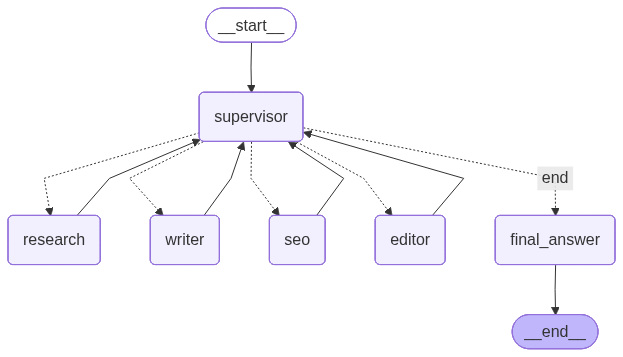

In [25]:
from IPython.display import Image, display

try:
    display(
        Image(
            app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 8단계: 시스템 테스트

실제 블로그 주제로 전체 프로세스를 테스트해봅니다.


### 테스트 케이스: LangChain 가이드 블로그


In [26]:
# 초기 상태 설정
initial_state = {
    "topic": "개발자를 위한 LangChain 시작 가이드",
    "target_audience": "Python을 다룰 줄 아는 주니어-미들 레벨 개발자"
}

print("=" * 80)
print("블로그 콘텐츠 제작 시작!")
print("=" * 80)
print(f"주제: {initial_state['topic']}")
print(f"타겟 독자: {initial_state['target_audience']}")
print("=" * 80)

# 그래프 실행
result = app.invoke(initial_state)

print("\n" + "=" * 80)
print("블로그 콘텐츠 제작 완료!")
print("=" * 80)


블로그 콘텐츠 제작 시작!
주제: 개발자를 위한 LangChain 시작 가이드
타겟 독자: Python을 다룰 줄 아는 주니어-미들 레벨 개발자

[Supervisor Agent] 현재 단계: start
[Router] start → research
[Research Agent] 조사 완료 (Tavily 연동)
조사 결과 길이: 4633 자

[Supervisor Agent] 현재 단계: research_completed
[Supervisor Agent] Research Agent 결과 승인 (PASS) → 다음 단계 진행
[Router] research_completed → writer
[Writer Agent] 초안 작성 완료
초안 길이: 4571 자

[Supervisor Agent] 현재 단계: draft_completed
[Supervisor Agent] Writer Agent 결과 반려 (FAIL) → 재시도 (1/2)
[Router] research_completed → writer
[Writer Agent] 초안 작성 완료
초안 길이: 4921 자

[Supervisor Agent] 현재 단계: draft_completed
[Supervisor Agent] Writer Agent 결과 반려 (FAIL) → 재시도 (2/2)
[Router] research_completed → writer
[Writer Agent] 초안 작성 완료
초안 길이: 4329 자

[Supervisor Agent] 현재 단계: draft_completed
[Supervisor Agent] Writer Agent 최대 재시도(2회) 초과 → 강제 통과
[Router] draft_completed → seo
[SEO Agent] SEO 분석 완료

[Supervisor Agent] 현재 단계: seo_completed
[Supervisor Agent] SEO Agent 결과 승인 (PASS) → 다음 단계 진행
[Router] seo_completed → editor
[Ed

### 최종 결과 확인


In [27]:
# 최종 블로그 포스트 출력
print(result["final_blog_post"])



# 블로그 콘텐츠 제작 완료

## 메타 정보
**주제:** 개발자를 위한 LangChain 시작 가이드
**타겟 독자:** Python을 다룰 줄 아는 주니어-미들 레벨 개발자

---

## 최종 콘텐츠

H1: 개발자를 위한 LangChain 시작 가이드: 파이썬에서 에이전트 구축하기

메타 디스크립션(SEO)
파이썬으로 LangChain을 시작하는 개발자를 위한 실전 가이드입니다. 에이전트 중심 흐름, Tools·Memory·스트리밍 등 핵심 구성요소를 설명하고 LangGraph와 Deep Agents 선택 방법까지 쉽게 제시합니다.

본문

흥미로운 시작
요즘은 모델 대결의 시대다 보니, 다양한 프로바이더(OpenAI, Anthropic, Google 등)를 한결같이 다루고, 에이전트가 알아서 문제를 해결하게 만드는 도구가 필요합니다. LangChain은 파이썬에서 표준화된 모델 인터페이스를 제공해 여러 모델 간의 교체를 쉽게 하고, 에이전트·도구·메모리·스트리밍 같은 구성요소를 한 흐름으로 다룰 수 있게 해줍니다. “에이전트를 10줄 이내로 구축 가능하다”는 말은 여전히 매력적입니다. 이제 LangChain의 기본 흐름부터 저수준 조정이 필요한 경우 LangGraph, 배터리 포함형 솔루션인 Deep Agents까지 선택의 폭이 넓어졌습니다. 이 글은 파이썬으로 LangChain을 시작하는 주니어-미들 개발자 여러분을 위한 실전 가이드입니다.

H2: 왜 LangChain인가
- LangChain의 핵심 아이디어
  - 표준 모델 인터페이스를 통해 서로 다른 모델 프로바이더를 쉽게 교체하고, 프로바이더 간 응답 형식 차이로 인한 잠금(lock-in)을 최소화합니다.
  - 흐름을 에이전트 중심으로 설계하고 도구(Tools), 메모리(Memory), 스트리밍(Streaming), 구조화된 출력(Structured output) 등 다양한 구성요소를 유연하게 연결합니다.
- 구성요소의 역할 요약
  - Agents: 문제 해결을 담당하는 결정 단위. 

### 단계별 작업 결과 확인


In [28]:
print("\nResearch Agent 조사 결과:")
print("-" * 80)
print(result["research_data"][:500] + "...\n")


Research Agent 조사 결과:
--------------------------------------------------------------------------------
다음은 개발자를 위한 LangChain 시작 가이드에 대한 공식 문서 기반 조사 요약입니다.

1) 주제의 핵심 개념 및 정의
- LangChain( Python):
  - 기본 아이디어: 표준화된 모델 인터페이스를 제공하여 서로 다른 모델 프로바이더(OpenAI, Anthropic, Google 등) 간의 교체를 쉽게 하며, 모델 호출의 응답 형식 차이로부터의 잠금(lock-in)을 최소화합니다. 핵심 구성 요소와 흐름을 일관되게 다룰 수 있게 해줍니다. 참조: LangChain 개요(Overview) 페이지. (자료 1)
  - 주요 구성 요소: Agents, Models, Messages, Tools, Memory, Streaming, Structured output 등. 고수준에서의 패턴부터 세부 구현까지 폭넓게 다룹니다. 예를 들어 “간단한 에이전트를 10줄 이내로 구축하는 것이 가능”하다고 소개합니다. (자료 1)
  - 사용 맥락: Quickstart 및 Getting ...



In [29]:
print("\nWriter Agent 초안:")
print("-" * 80)
print(result["draft_content"][:500] + "...\n")


Writer Agent 초안:
--------------------------------------------------------------------------------
주제: 개발자를 위한 LangChain 시작 가이드

흥미로운 시작
요즘 모델 대결의 시대다 보니, 서로 다른 프로바이더(OpenAI, Anthropic, Google 등)를 한결같이 다루고, 에이전트가 알아서 문제를 해결하게 만드는 도구가 필요합니다. LangChain은 파이썬에서 표준화된 모델 인터페이스를 제공해 여러 모델 간의 교체를 쉽게 하고, 에이전트·도구·메모리·스트리밍 같은 구성요소를 한 흐름으로 다룰 수 있게 해줍니다. “에이전트를 10줄 이내로 구축 가능하다”는 말이 초보자에게도 매력적으로 들리죠. 지금은 LangChain의 기본 흐름부터, 저수준 조정이 필요한 경우 LangGraph, 그리고 배터리 포함형 솔루션인 Deep Agents까지 선택의 폭이 넓어졌습니다. 이 글은 파이썬으로 LangChain을 시작하는 주니어-미들 개발자 여러분을 위한 실전 가이드입니다.

본론

1) LangChain의 기본 흐름과 주요 구성요소
- 핵심 아이디어
  - 표준 모델 인터...



In [30]:
print("\nSEO Agent 권장사항:")
print("-" * 80)
print(result["seo_recommendations"][:500] + "...\n")


SEO Agent 권장사항:
--------------------------------------------------------------------------------
다음은 초안에 대한 SEO 중심의 실행 가능 권장사항입니다.

1) 추천 키워드 5-7개 (주 키워드 + 롱테일 키워드)
- 주 키워드
  - LangChain 시작 가이드
- 롱테일 키워드
  - LangChain 파이썬 시작 가이드
  - LangChain 에이전트 구성 요소
  - LangGraph 사용법
  - Deep Agents 소개
  - LangChain 기본 흐름
  - LangChain 튜토리얼 파이썬

추가로 사용할 수 있는 변형 키워드
- LangChain 파이썬 에이전트
- LangChain 도구 메모리 구성
- LangChain 실전 예제 파이썬

팁: 본문 각섹션의 제목(H2/H3)에도 위 키워드를 자연스럽게 포함시키되, 키워드 남용은 피하세요.

2) 메타 디스크립션 제안 (150-160자)
파이썬으로 LangChain을 시작하는 개발자를 위한 실전 가이드입니다. 에이전트 중심 흐름, Tools·Memory·스트리밍 등 핵심 구성요소를 설명하고 LangG...



In [31]:
print("\nEditor Agent 최종 편집본:")
print("-" * 80)
print(result["edited_content"][:500] + "...\n")



Editor Agent 최종 편집본:
--------------------------------------------------------------------------------
H1: 개발자를 위한 LangChain 시작 가이드: 파이썬에서 에이전트 구축하기

메타 디스크립션(SEO)
파이썬으로 LangChain을 시작하는 개발자를 위한 실전 가이드입니다. 에이전트 중심 흐름, Tools·Memory·스트리밍 등 핵심 구성요소를 설명하고 LangGraph와 Deep Agents 선택 방법까지 쉽게 제시합니다.

본문

흥미로운 시작
요즘은 모델 대결의 시대다 보니, 다양한 프로바이더(OpenAI, Anthropic, Google 등)를 한결같이 다루고, 에이전트가 알아서 문제를 해결하게 만드는 도구가 필요합니다. LangChain은 파이썬에서 표준화된 모델 인터페이스를 제공해 여러 모델 간의 교체를 쉽게 하고, 에이전트·도구·메모리·스트리밍 같은 구성요소를 한 흐름으로 다룰 수 있게 해줍니다. “에이전트를 10줄 이내로 구축 가능하다”는 말은 여전히 매력적입니다. 이제 LangChain의 기본 흐름부터 저수준 조정이 필요한 경우 LangGraph, 배터리 ...



### [Langsmith](https://smith.langchain.com/)

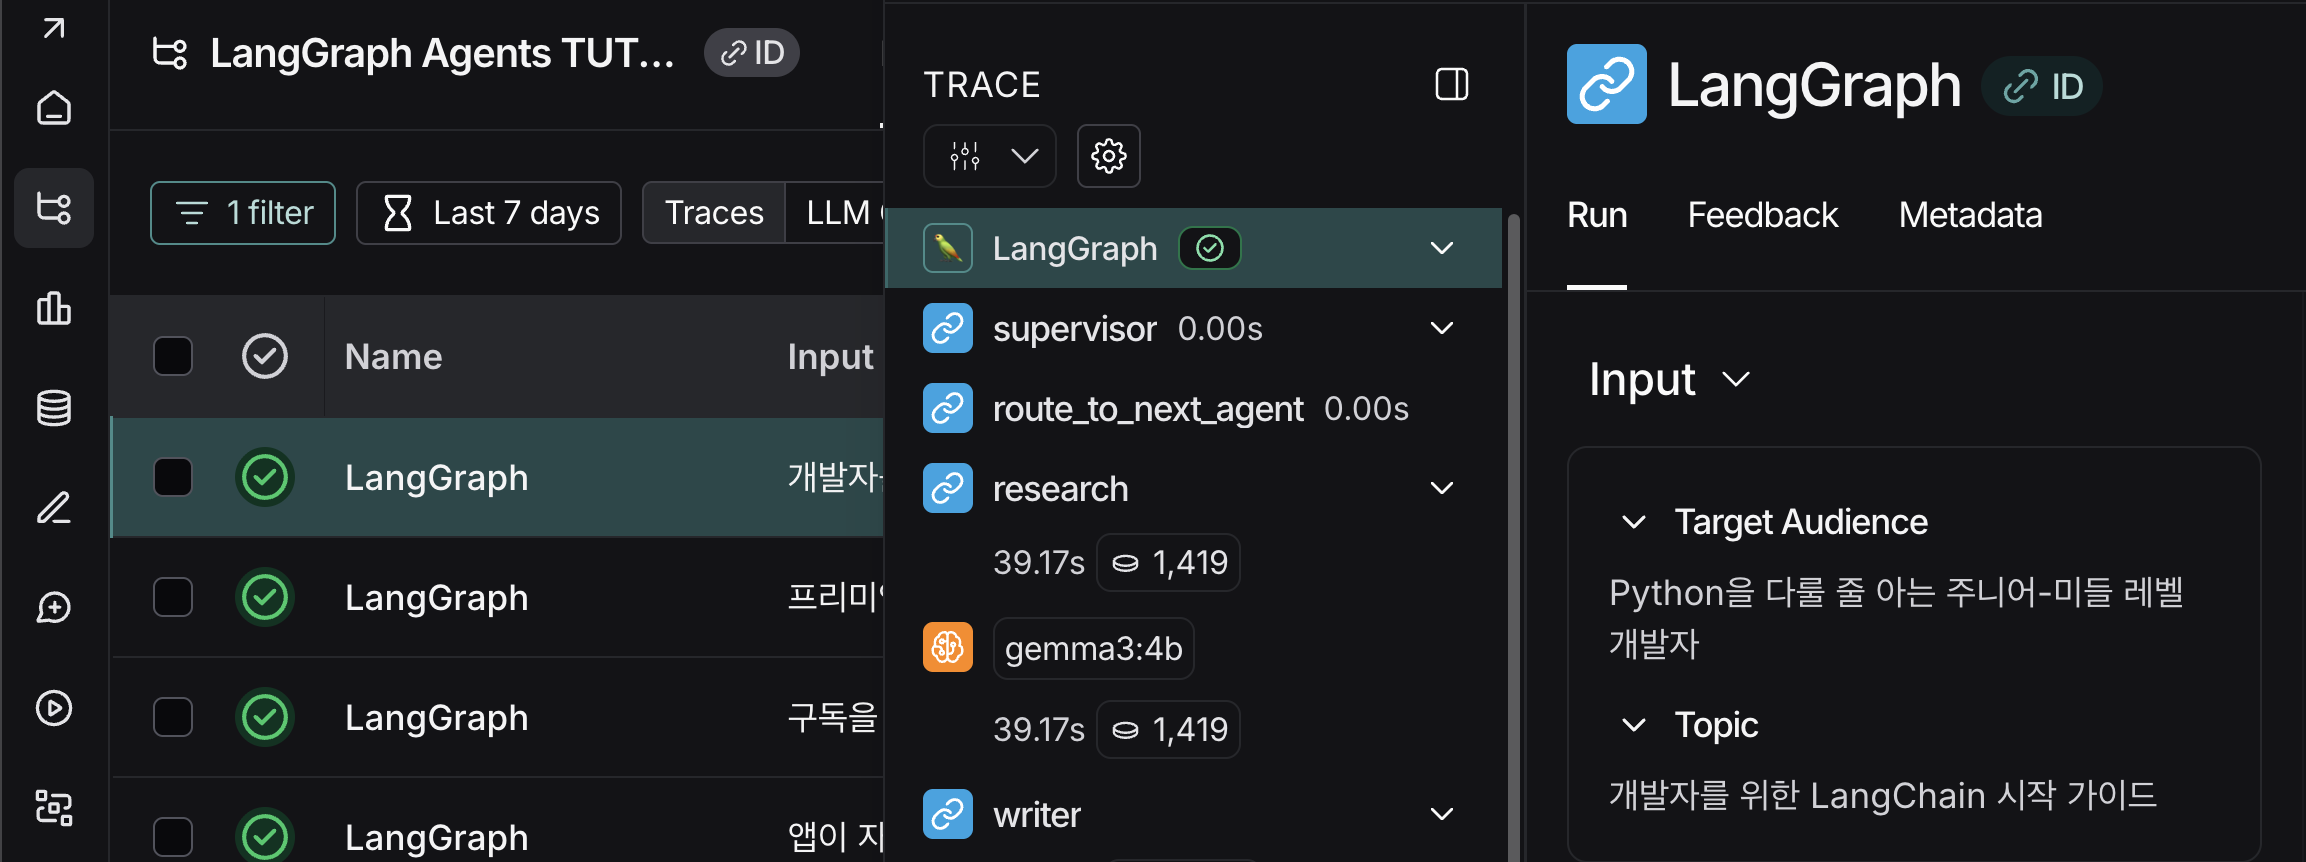